In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
results = []

paths = os.listdir('./perceptron/')
paths.sort()
for name in paths:
    if os.path.isfile("./perceptron/" + name):
        if name[-4:] == ".txt":
            res = pd.read_csv("./perceptron/" + name, delimiter = "\\")
            result = ""
            for line in res.iloc[:, 0]:
                if line.startswith("CPU 0 Branch Prediction Accuracy:"):
                    result = line.split(" ")[5][:-1]
            if result != "":
                results.append((name[:-4], result))
results

[('10', '80.28'),
 ('100', '81.82'),
 ('1000', '92.47'),
 ('10000', '97.06'),
 ('100000', '98.88'),
 ('1000000', '97.67'),
 ('10000000', '100')]

In [16]:
# BHT
resultsBHT = []

paths = os.listdir('./bht/')
paths.sort()
for name in paths:
    if os.path.isfile("./bht/" + name):
        if name[-4:] == ".txt":
            res = pd.read_csv("./bht/" + name, delimiter = "\\")
            result = ""
            for line in res.iloc[:, 0]:
                if line.startswith("CPU 0 Branch Prediction Accuracy:"):
                    result = line.split(" ")[5][:-1]
            if result != "":
                resultsBHT.append((name[:-4], result))
resultsBHT

[('10', '69.12'),
 ('100', '71.62'),
 ('1000', '69.62'),
 ('10000', '68'),
 ('100000', '73.58'),
 ('1000000', '70.59'),
 ('10000000', '69.39')]

In [21]:
# Tournament
resultsTOUR = []

paths = os.listdir('./tour/')
paths.sort()
for name in paths:
    if os.path.isfile("./tour/" + name):
        if name[-4:] == ".txt":
            res = pd.read_csv("./tour/" + name, delimiter = "\\")
            result = ""
            for line in res.iloc[:, 0]:
                if line.startswith("CPU 0 Branch Prediction Accuracy:"):
                    result = line.split(" ")[5][:-1]
                # if line.startswith("Conditional Branch Prediction Accuracy"):
                #     result = line.split(" ")[4][1:]
            if result != "":
                resultsTOUR.append((name[:-4], result))
resultsTOUR

[('10', '93.83'),
 ('100', '94.51'),
 ('1000', '95.65'),
 ('10000', '100'),
 ('100000', '98.88'),
 ('1000000', '97.67'),
 ('10000000', '100')]

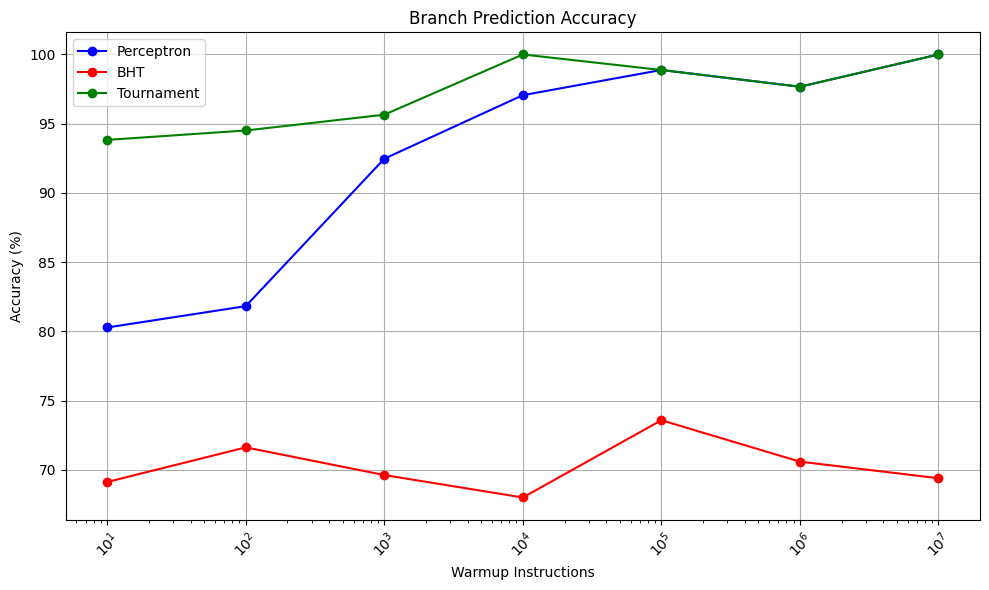

In [22]:
# Plot graph!
plt.figure(figsize=(10, 6))
plt.title("Branch Prediction Accuracy")
plt.xlabel("Warmup Instructions")
plt.xscale('log')
plt.ylabel("Accuracy (%)")

# Perceptron
x = []
y = []
for result in results:
    x.append(int(result[0]))
    y.append(float(result[1]))
plt.plot(x, y, marker='o', linestyle='-', color='b', label='Perceptron')

# BHT
x = []
y = []
for result in resultsBHT:
    x.append(int(result[0]))
    y.append(float(result[1]))
# Add another line on same graph for BHT
plt.plot(x, y, marker='o', linestyle='-', color='r', label='BHT')

# TOUR
x = []
y = []
for result in resultsTOUR:
    x.append(int(result[0]))
    y.append(float(result[1]))
# Add another line on same graph for Tournament
plt.plot(x, y, marker='o', linestyle='-', color='g', label='Tournament')

# Add a legend
plt.legend(loc='upper left')

plt.xticks(x, rotation=45)
plt.grid()
plt.tight_layout()
plt.savefig("branch_prediction_accuracy.png")
plt.show()